In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)
import xgboost as xgb

from google.colab import drive
drive.mount('/content/drive')

# --- 1. Load data ---
X = pd.read_csv('/content/drive/MyDrive/datasets/undersampled_features.csv')
y = pd.read_csv('/content/drive/MyDrive/datasets/undersampled_target.csv')['Diabetes_binary']

print(f"Features: {X.shape}, Target distribution:\n{y.value_counts(normalize=True)}\n")

# --- 2. Best hyperparameters from RandomizedSearchCV (best_params = search.best_params_) ---
best_params = {
    'max_depth': 4,
    'learning_rate': 0.05,
    'n_estimators': 100,
    'subsample': 0.9,
    'colsample_bytree': 0.8,
}

def make_model():
    return xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
        **best_params,
    )

# --- 3. 5-fold stratified CV ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

fold_metrics = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = make_model()
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]

    m = {
        'acc':  accuracy_score(y_val, y_pred),
        'prec': precision_score(y_val, y_pred, zero_division=0),
        'rec':  recall_score(y_val, y_pred),
        'f1':   f1_score(y_val, y_pred),
        'auc':  roc_auc_score(y_val, y_proba),
    }
    for k, v in m.items():
        fold_metrics[k].append(v)

    print(f"Fold {fold}: "
          f"acc {m['acc']:.4f} | prec {m['prec']:.4f} | rec {m['rec']:.4f} "
          f"| f1 {m['f1']:.4f} | auc {m['auc']:.4f}")

# --- 4. Mean ± std summary ---
print("\n===== 5-Fold CV Summary (mean ± std) =====")
for k, v in fold_metrics.items():
    print(f"{k.upper():5s}: {np.mean(v):.4f} ± {np.std(v):.4f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Features: (56554, 28), Target distribution:
Diabetes_binary
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64

Fold 1: acc 0.7502 | prec 0.7342 | rec 0.7844 | f1 0.7585 | auc 0.8265
Fold 2: acc 0.7441 | prec 0.7266 | rec 0.7828 | f1 0.7537 | auc 0.8219
Fold 3: acc 0.7494 | prec 0.7285 | rec 0.7951 | f1 0.7603 | auc 0.8267
Fold 4: acc 0.7525 | prec 0.7326 | rec 0.7951 | f1 0.7626 | auc 0.8328
Fold 5: acc 0.7513 | prec 0.7319 | rec 0.7931 | f1 0.7613 | auc 0.8279

===== 5-Fold CV Summary (mean ± std) =====
ACC  : 0.7495 ± 0.0029
PREC : 0.7308 ± 0.0028
REC  : 0.7901 ± 0.0054
F1   : 0.7593 ± 0.0031
AUC  : 0.8272 ± 0.0035



--- Evaluating XGBoost Model ---

--- XGBoost Evaluation Metrics ---
Accuracy:  0.7570
Precision: 0.7365
Recall:    0.8005
F1-Score:  0.7672
Confusion matrix:
[[4035 1620]
 [1128 4527]]
ROC AUC: 0.8320
PR AUC:  0.8085


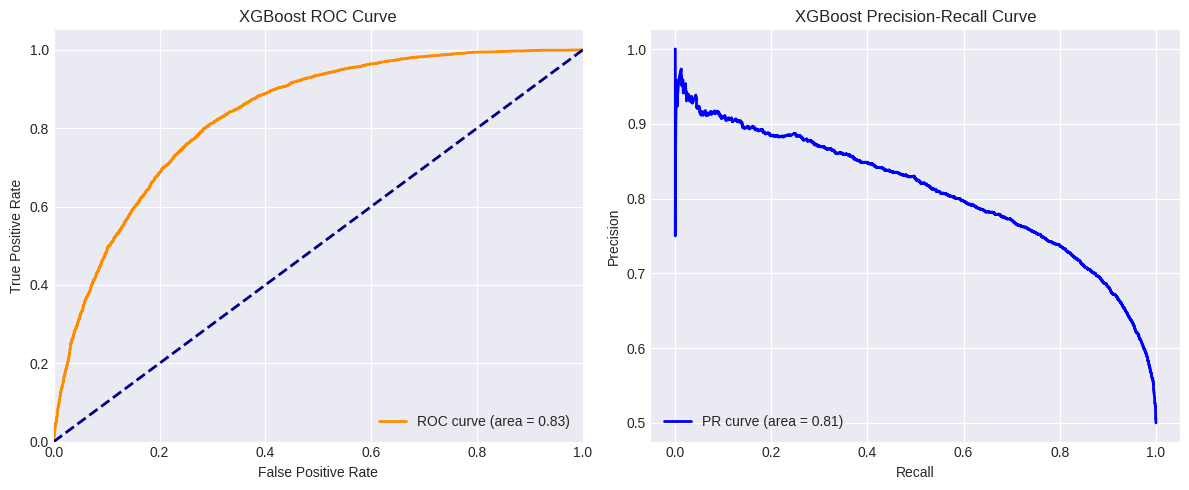

In [12]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np
import joblib

print("\n--- Evaluating XGBoost Model ---")

# Directly load model and use existing validation sets
xgb_model = joblib.load('/content/drive/MyDrive/models/xgboost_diabetes_model.joblib')

xgb_preds = xgb_model.predict(X_val)
xgb_probs = xgb_model.predict_proba(X_val)[:, 1]

# Calculate metrics
xgb_accuracy = accuracy_score(y_val, xgb_preds)
xgb_precision = precision_score(y_val, xgb_preds, zero_division=0)
xgb_recall = recall_score(y_val, xgb_preds)
xgb_f1 = f1_score(y_val, xgb_preds)
xgb_cm = confusion_matrix(y_val, xgb_preds)

print(f"\n--- XGBoost Evaluation Metrics ---")
print(f"Accuracy:  {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall:    {xgb_recall:.4f}")
print(f"F1-Score:  {xgb_f1:.4f}")
print(f"Confusion matrix:\n{xgb_cm}")

# Curves

# ROC Curve - Graph plotting the True Positive Rate (TPR) on the y-axis against the False Positive Rate (FPR)
# Precision Recall Curve - Plots Precision (y-axis) against Recall (x-axis) across all possible classification probability thresholds

xgb_fpr, xgb_tpr, _ = roc_curve(y_val, xgb_probs)
xgb_roc_auc = auc(xgb_fpr, xgb_tpr)
xgb_precision_curve, xgb_recall_curve, _ = precision_recall_curve(y_val, xgb_probs)
xgb_pr_auc = auc(xgb_recall_curve, xgb_precision_curve)

print(f"ROC AUC: {xgb_roc_auc:.4f}")
print(f"PR AUC:  {xgb_pr_auc:.4f}")

# Plotting
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(xgb_fpr, xgb_tpr, color='darkorange', lw=2, label=f'ROC curve (area = {xgb_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve')
plt.legend(loc="lower right")

plt.subplot(1, 2, 2)
plt.plot(xgb_recall_curve, xgb_precision_curve, color='blue', lw=2, label=f'PR curve (area = {xgb_pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('XGBoost Precision-Recall Curve')
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()